# **Libraries and Dependencies**

In [1]:
import os
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from torchvision.ops import box_iou
from tqdm import tqdm

from sklearn.metrics import (
    precision_score, recall_score,
    f1_score, accuracy_score,
    confusion_matrix
)

# **Dataset Paths and Class Definitions**

In [2]:
train_root = "/kaggle/input/railway-datasets/Railway_Train"
val_root   = "/kaggle/input/railway-datasets/Railway_Val"
test_root  = "/kaggle/input/railway-datasets/Railway_Test"

In [3]:
CLASSES = {
    0: "Bolt",
    1: "Fastener",
    2: "Railcrack"
}
NUM_CLASSES = len(CLASSES) + 1  # + background

# **Custom Dataset Class**

In [4]:
class RailwayDataset(Dataset):
    def __init__(self, root):
        self.images = []
        self.labels = []

        for cls in os.listdir(root):
            img_dir = os.path.join(root, cls, "images")
            lbl_dir = os.path.join(root, cls, "labels")

            for img in os.listdir(img_dir):
                self.images.append(os.path.join(img_dir, img))
                self.labels.append(os.path.join(lbl_dir, img.replace(".jpg", ".txt")))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        w, h = img.size

        boxes = []
        labels = []

        with open(self.labels[idx]) as f:
            for line in f:
                cls, xc, yc, bw, bh = map(float, line.split())

                x_min = (xc - bw/2) * w
                y_min = (yc - bh/2) * h
                x_max = (xc + bw/2) * w
                y_max = (yc + bh/2) * h

                boxes.append([x_min, y_min, x_max, y_max])
                labels.append(int(cls) + 1)

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64)
        }

        return F.to_tensor(img), target

# **DataLoader and Batch Handling**

In [5]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    RailwayDataset(train_root),
    batch_size=16, shuffle=True, collate_fn=collate_fn, num_workers=2
)

val_loader = DataLoader(
    RailwayDataset(val_root),
    batch_size=16, shuffle=False, collate_fn=collate_fn, num_workers=2
)

test_loader = DataLoader(
    RailwayDataset(test_root),
    batch_size=16, shuffle=False, collate_fn=collate_fn, num_workers=2
)

# **Model Initialization and Training Configuration**

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load base model
model = retinanet_resnet50_fpn(weights="DEFAULT")

# Get number of anchors
num_anchors = model.head.classification_head.num_anchors

# Replace classification head PROPERLY
model.head.classification_head = RetinaNetClassificationHead(
    in_channels=256,
    num_anchors=num_anchors,
    num_classes=NUM_CLASSES
)

model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth" to /root/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_coco-eeacb38b.pth


100%|██████████| 130M/130M [00:00<00:00, 178MB/s]  


# **Detection Accuracy Metric**

In [7]:
def detection_accuracy(model, loader, device, iou_thr=0.5):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            outputs = model(images)

            for pred, gt in zip(outputs, targets):

                if len(pred["boxes"]) == 0 or len(gt["boxes"]) == 0:
                    continue

                # ✅ MOVE GT TO SAME DEVICE
                gt_boxes = gt["boxes"].to(device)
                gt_labels = gt["labels"].to(device)

                pred_boxes = pred["boxes"]
                pred_labels = pred["labels"]

                ious = box_iou(pred_boxes, gt_boxes)
                max_iou, idx = ious.max(dim=1)

                for i, iou in enumerate(max_iou):
                    if iou >= iou_thr:
                        total += 1
                        if pred_labels[i] == gt_labels[idx[i]]:
                            correct += 1

    return correct / total if total > 0 else 0

# **Validation Loss Computation**

In [8]:
def compute_val_loss(model, loader, device):
    model.train()  # RetinaNet computes loss only in train mode
    total_loss = 0.0

    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())
            total_loss += loss.item()

    model.eval()
    return total_loss

# **mAP@0.5 Computation**

In [9]:
def compute_map50(model, loader, device, iou_thr=0.5):
    model.eval()
    tp, total = 0, 0

    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            outputs = model(images)

            for pred, gt in zip(outputs, targets):
                if len(pred["boxes"]) == 0 or len(gt["boxes"]) == 0:
                    continue

                gt_boxes = gt["boxes"].to(device)
                pred_boxes = pred["boxes"]

                ious = box_iou(pred_boxes, gt_boxes)
                tp += (ious.max(dim=1)[0] >= iou_thr).sum().item()
                total += len(gt_boxes)

    return tp / total if total > 0 else 0

# **Model Training**

In [10]:
num_epochs = 50

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
val_map50 = []

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0.0

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    progress_bar = tqdm(train_loader, desc="Training", leave=False)

    for images, targets in progress_bar:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

        progress_bar.set_postfix({
            "Train Loss": f"{loss.item():.4f}"
        })

    # ---- Metrics ----
    train_loss = epoch_train_loss
    val_loss   = compute_val_loss(model, val_loader, device)

    train_acc = detection_accuracy(model, train_loader, device)
    val_acc   = detection_accuracy(model, val_loader, device)

    map50 = compute_map50(model, val_loader, device)

    # ---- Store ----
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    val_map50.append(map50)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val mAP@0.5: {map50:.4f}"
    )


Epoch [1/50]


Epoch [1/50] | Train Loss: 118.1116 | Val Loss: 25.2634 | Train Acc: 0.4134 | Val Acc: 0.4113 | Val mAP@0.5: 4.5584

Epoch [2/50]


Epoch [2/50] | Train Loss: 55.2108 | Val Loss: 18.4940 | Train Acc: 0.5331 | Val Acc: 0.5526 | Val mAP@0.5: 3.9591

Epoch [3/50]


Epoch [3/50] | Train Loss: 39.2527 | Val Loss: 14.8906 | Train Acc: 0.5926 | Val Acc: 0.6067 | Val mAP@0.5: 3.0782

Epoch [4/50]


Epoch [4/50] | Train Loss: 33.8888 | Val Loss: 15.3596 | Train Acc: 0.6566 | Val Acc: 0.6662 | Val mAP@0.5: 2.4513

Epoch [5/50]


...

Epoch [46/50] | Train Loss: 4.5567 | Val Loss: 13.4002 | Train Acc: 0.8413 | Val Acc: 0.8931 | Val mAP@0.5: 1.1143

Epoch [47/50]


Epoch [47/50] | Train Loss: 4.8027 | Val Loss: 13.9113 | Train Acc: 0.8044 | Val Acc: 0.8701 | Val mAP@0.5: 1.1300

Epoch [48/50]


Epoch [48/50] | Train Loss: 4.8054 | Val Loss: 13.4131 | Train Acc: 0.8538 | Val Acc: 0.8989 | Val mAP@0.5: 1.1098

Epoch [49/50]


Epoch [49/50] | Train Loss: 4.7167 | Val Loss: 13.5319 | Train Acc: 0.8584 | Val Acc: 0.9001 | Val mAP@0.5: 1.0989

Epoch [50/50]


Epoch [50/50] | Train Loss: 4.5808 | Val Loss: 14.3149 | Train Acc: 0.8341 | Val Acc: 0.8877 | Val mAP@0.5: 1.1184


# **Prediction–Ground Truth Matching**

In [12]:
from torchvision.ops import box_iou

def match_predictions(pred, gt, iou_thr=0.5):
    if len(pred["boxes"]) == 0 or len(gt["boxes"]) == 0:
        return [], []

    ious = box_iou(pred["boxes"], gt["boxes"])
    max_iou, gt_idx = ious.max(dim=1)

    matched = max_iou >= iou_thr
    y_pred = pred["labels"][matched].cpu().numpy()
    y_true = gt["labels"][gt_idx[matched]].cpu().numpy()

    return y_true.tolist(), y_pred.tolist()

In [13]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="Evaluating Test Set"):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        outputs = model(images)

        for pred, gt in zip(outputs, targets):
            yt, yp = match_predictions(pred, gt, iou_thr=0.5)
            y_true.extend(yt)
            y_pred.extend(yp)

Evaluating Test Set: 100%|██████████| 38/38 [00:41<00:00,  1.08s/it]


# **Test Set Evaluation Metrics**

In [14]:
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall    = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1        = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

Accuracy  : 0.8759
Precision : 0.8809
Recall    : 0.8759
F1-score  : 0.8773


# **mAP@0.5 Evaluation**

In [15]:
from tqdm import tqdm
from torchvision.ops import box_iou

def compute_map50_fast(model, loader, device):
    model.eval()
    tp, total = 0, 0

    with torch.no_grad():
        for images, targets in tqdm(loader, desc="Computing mAP@0.5"):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            outputs = model(images)

            for pred, gt in zip(outputs, targets):
                if pred["boxes"].numel() == 0 or gt["boxes"].numel() == 0:
                    continue

                # Compute IoU
                ious = box_iou(pred["boxes"], gt["boxes"])

                # Count true positives
                tp += (ious.max(dim=1)[0] >= 0.5).sum().item()
                total += gt["boxes"].size(0)

    return tp / total if total > 0 else 0

map_50 = compute_map50_fast(model, test_loader, device)
print(f"mAP@0.5 : {map_50:.4f}")

Computing mAP@0.5: 100%|██████████| 38/38 [00:40<00:00,  1.07s/it]

mAP@0.5 : 1.1293


# **Confusion Matrix Visualization**

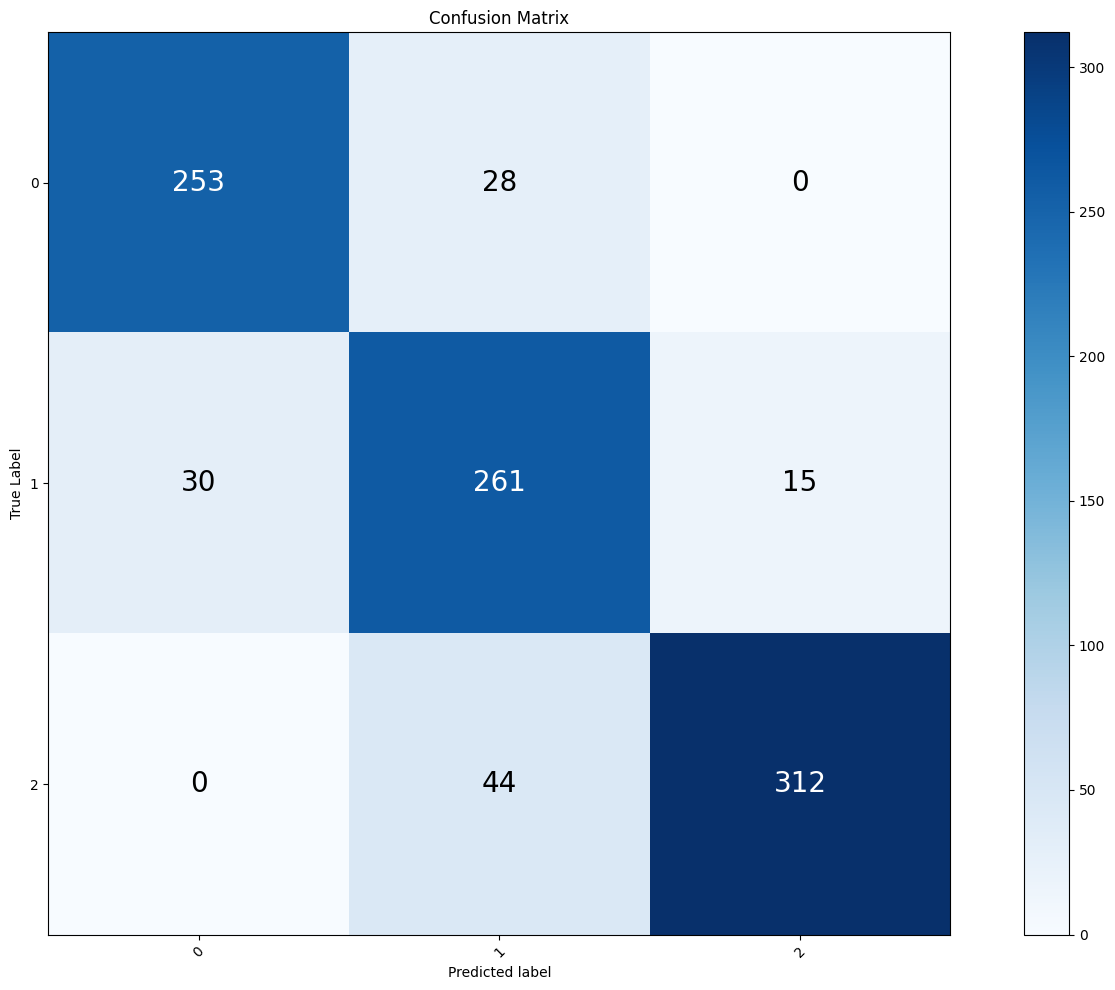

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(15,10))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True Label")
plt.colorbar()

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max()/2 else "black",
            fontsize=20
        )

plt.xticks(np.arange(len(CLASSES)), CLASSES, rotation=45)
plt.yticks(np.arange(len(CLASSES)), CLASSES)

plt.tight_layout()
plt.show()

# **Accuracy Curve Visualization**

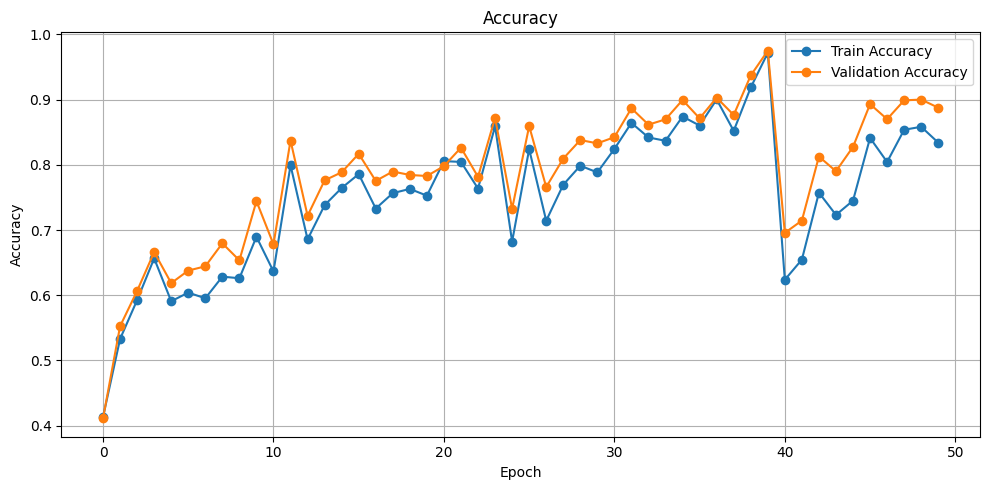

In [17]:
plt.figure(figsize=(10,5))
plt.plot(train_accuracies, marker='o', label="Train Accuracy")
plt.plot(val_accuracies, marker='o', label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# **Loss Curve Visualization**

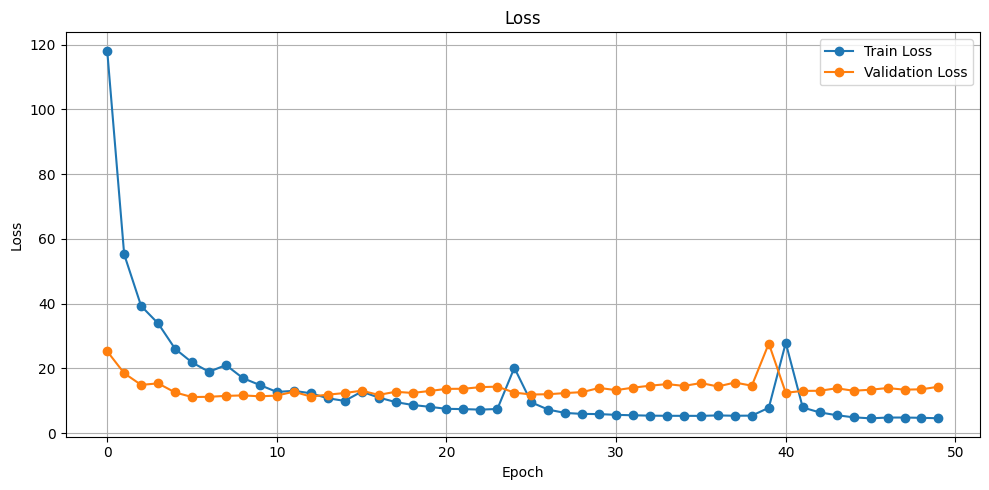

In [18]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, marker='o', label="Train Loss")
plt.plot(val_losses, marker='o', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()